<a href="https://colab.research.google.com/github/rokeyacse-kyau/ImageSegmentationModel/blob/main/Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 : Set up colab gpu runtime environment



In [1]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.9 MB/s eta 0:00:00
  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-lr61m_ym
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-lr61m_ym
  Resolved https://github.com/albumentations-team/albumentations to commit 66212d77a44927a29d6a0e81621d3c27afbd929c
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


# Download Dataset

original author of the dataset :
https://github.com/akabircs/WoundTissue


In [2]:
!git clone https://github.com/akabircs/WoundTissue.git

Cloning into 'WoundTissue'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 96 (delta 28), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 973.93 KiB | 4.70 MiB/s, done.
Resolving deltas: 100% (28/28), done.


# Some Common Imports

In [3]:
import sys
sys.path.append('/content/WoundTissue')

In [4]:
import torch
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm


In [5]:
DATA_DIR = '/content/'
DEVICE = 'cuda'

EPOCHS = 30 #25
LR = 0.002 #.003
IMAGE_SIZE = 320
BATCH_SIZE = 16
ENCODER = 'resnet18' #'timm-efficientnet-b0'
WEIGHTS = 'imagenet'

In [6]:
import os
import pandas as pd

image_dir = "WoundTissue/image"
mask_dir = "WoundTissue/label"

data = []

for img_name in os.listdir(image_dir):
    if img_name.endswith(".png"):   # both PNG

        img_path = os.path.join(image_dir, img_name)

        # same name for mask
        mask_name = img_name
        mask_path = os.path.join(mask_dir, mask_name)

        if os.path.exists(mask_path):
            data.append([mask_path, img_path])
        else:
            print(f"Mask not found: {img_name}")

df = pd.DataFrame(data, columns=["masks", "images"])
df.to_csv("WoundTissue/train.csv", index=False)

print("train.csv created successfully!")

train.csv created successfully!


In [7]:
CSV_FILE = '/content/WoundTissue/train.csv'

In [8]:
df = pd.read_csv(CSV_FILE)
df.head()

,masks,images
0,WoundTissue/label/img (23).png,WoundTissue/image/img (23).png
1,WoundTissue/label/img (6).png,WoundTissue/image/img (6).png
2,WoundTissue/label/img (27).png,WoundTissue/image/img (27).png
3,WoundTissue/label/img (2).png,WoundTissue/image/img (2).png
4,WoundTissue/label/img (31).png,WoundTissue/image/img (31).png


In [9]:
row = df.iloc[4]
image_path = row.images
mask_path = row.masks

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)/255.0

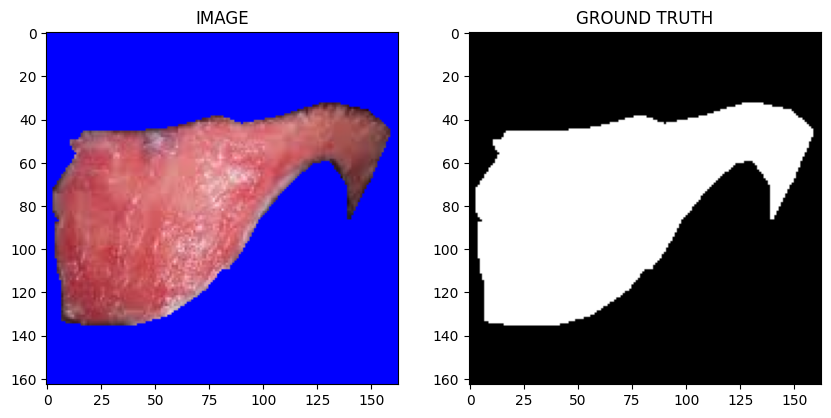

In [10]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH')
ax2.imshow(mask,cmap = 'gray')

In [11]:
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

# Task 3 : Augmentation Functions

In [12]:
import albumentations as A


In [13]:
def get_train_augs():
  return A.Compose([
      A.Resize(IMAGE_SIZE, IMAGE_SIZE),
      A.HorizontalFlip( p = 0.5),
      A.VerticalFlip( p = 0.5)
  ], is_check_shapes=False)
def get_valid_augs():
  return A.Compose([
      A.Resize(IMAGE_SIZE, IMAGE_SIZE)
  ], is_check_shapes=False)

# Task 4 : Create Custom Dataset

In [14]:
from torch.utils.data import Dataset

In [15]:
class SegmentationDataset(Dataset):
  def __init__(self, df, augmentations):
    self.df = df
    self.augmentations = augmentations
  def __len__(self):
    return len(self.df)
  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    image_path = row.images
    mask_path = row.masks

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) #(H, W, C)
    mask = np.expand_dims(mask, axis = -1) #(H, W, 1)

    if self.augmentations:
      data = self.augmentations(image = image, mask = mask)
      image = data['image']
      mask = data['mask']

      #(h, w, c) = (c, h, w)
      image = np.transpose(image, (2, 0, 1)).astype(np.float32)
      mask = np.transpose(mask, (2, 0, 1)).astype(np.float32)

      image = torch.Tensor(image)/255.0  # value o to 1 er modhe rakher jopnno 255 dia vaag kora hoice
      mask = torch.round(torch.Tensor(mask)/255.0)

      return image, mask
      mask = torch.round(torch.Tensor(mask)/255.0)
      return image, mask

In [16]:
trainset = SegmentationDataset(train_df, get_train_augs())
validset = SegmentationDataset(valid_df, get_valid_augs())

In [17]:
print(f"Size of Trainset : {len(trainset)}")
print(f"Size of Validset : {len(validset)}")

Size of Trainset : 10
Size of Validset : 3


In [18]:
# idx = 2
# model.load_state_dict(torch.load('/content/best_model.pth'))
# image, mask = validset[idx]
# logits_mask = model(image.to(DEVICE).unsqueeze(0)) #(c, h, w) --> (1, c, h, w)
# pred_mask = torch.sigmoid(logits_mask)
# pred_mask = (pred_mask > 0.5) * 1.0

NameError: name 'model' is not defined

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch


def show_image(image,mask,pred_image = None):

    if pred_image == None:

        f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

        ax1.set_title('IMAGE')
        ax1.imshow(image.permute(1,2,0).squeeze(),cmap = 'gray')

        ax2.set_title('GROUND TRUTH')
        ax2.imshow(mask.permute(1,2,0).squeeze(),cmap = 'gray')

    elif pred_image != None :

        f, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(10,5))

        ax1.set_title('IMAGE')
        ax1.imshow(image.permute(1,2,0).squeeze(),cmap = 'gray')

        ax2.set_title('GROUND TRUTH')
        ax2.imshow(mask.permute(1,2,0).squeeze(),cmap = 'gray')

        ax3.set_title('MODEL OUTPUT')
        ax3.imshow(pred_image.permute(1,2,0).squeeze(),cmap = 'gray')




In [ ]:
idx = 3
image, mask = trainset[idx]
show_image(image, mask)


# Task 5 : Load dataset into batches

In [ ]:
from torch.utils.data import DataLoader

In [ ]:
trainloader = DataLoader(trainset, batch_size = BATCH_SIZE, shuffle = True)
validloader = DataLoader(validset,batch_size = BATCH_SIZE)

In [ ]:
print(f"Total number of batches in trainloader : {len(trainloader)}")
print(f"Total number of batches in validloader : {len(validloader)}")

In [ ]:
for image, mask in trainloader:
  break
print(f" One batch image shape : {image.shape}")
print(f"One batch mask shape : {mask.shape}")

# Task 6 : Create Segmentation Model

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [ ]:
from torch import nn
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

In [ ]:
from IPython.utils.py3compat import encode
class SegmentationModel(nn.Module):
  def __init__(self):
    super(SegmentationModel, self).__init__()

    self.arc = smp.Unet(
        encoder_name = ENCODER,
        encoder_weights = WEIGHTS,
        in_channels = 3,
        classes = 1,
        activation = None
    )
  def forward(self, images, masks = None):
    logits = self.arc(images)

    if masks != None:
      loss1 = DiceLoss(mode = 'binary')(logits, masks)
      loss2 = nn.BCEWithLogitsLoss()(logits, masks)
      return logits, loss1 + loss2
    return logits

In [ ]:
model = SegmentationModel()
model.to(DEVICE);

# Task 7 : Create Train and Validation Function

In [ ]:
def train_fn(data_loader, model, optimizer):
  model.train()
  total_loss = 0

  for images, masks in tqdm(data_loader):
    images = images.to(DEVICE)
    masks = masks.to(DEVICE)

    optimizer.zero_grad()
    logits, loss = model(images, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  return total_loss/len(data_loader)


In [ ]:
def eval_fn(data_loader, model):
  model.eval()
  total_loss = 0

  with torch.no_grad():
    for images, masks in tqdm(data_loader):
      images = images.to(DEVICE)
      masks = masks.to(DEVICE)
      logits, loss = model(images, masks)
      total_loss += loss.item()
      return total_loss/len(data_loader)


# Task 8 : Train Model

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr = LR)

In [ ]:
best_valid_loss = np.inf

for i in range(EPOCHS):
  train_loss = train_fn(trainloader, model, optimizer)
  valid_loss = eval_fn(validloader, model)

  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), 'best_model.pth')
    print("Saved Best Model!")

  print(f"Epoch : {i+1} Train Loss : {train_loss} Valid Loss : {valid_loss}")

# Task 9 : Inference

In [ ]:
idx = 2
model.load_state_dict(torch.load('/content/best_model.pth'))
image, mask = validset[idx]
logits_mask = model(image.to(DEVICE).unsqueeze(0)) #(c, h, w) --> (1, c, h, w)
pred_mask = torch.sigmoid(logits_mask)
pred_mask = (pred_mask > 0.5) * 1.0

In [ ]:
show_image(image, mask, pred_mask.detach().cpu().squeeze(0))